# Bluesky US Election 2024 — Mention Network Analysis

**Who talks about whom?** We model every `@mention` in election posts as a directed edge and study the structure of the resulting network.

### Framing: buzz clusters, not supporter groups
Posts are grouped into three **hashtag clusters** based on the hashtag that retrieved them — not on the author's political stance:

| Label | Meaning | ⚠ What it is NOT |
|---|---|---|
| 🔴 **TrumpBuzz** | Found via a Trump-related hashtag (`#MAGA`, `#Trump2024`, …) | Does NOT mean the author supports Trump |
| 🔵 **HarrisBuzz** | Found via a Harris-related hashtag (`#KamalaHarris`, `#VoteBlue`, …) | Does NOT mean the author supports Harris |
| ⚪ **ElectionBuzz** | Found via neutral election hashtags or comments | No candidate association |

A post in TrumpBuzz may be critical of Trump — it simply circulated in Trump-related hashtag spaces. The network analysis therefore captures **attention and conversation volume** around each candidate, not partisan loyalty.

<!-- toc -->
## Contents
- **[Bluesky US Election 2024 — Mention Network Analysis](#bluesky-us-election-2024-mention-network-analysis)**
    - [Framing: buzz clusters, not supporter groups](#framing-buzz-clusters-not-supporter-groups)
  - [1 · Setup](#1-setup)
  - [2 · Data](#2-data)
  - [3 · Network Construction](#3-network-construction)
  - [4 · Network Structure & Statistics](#4-network-structure-statistics)
  - [5 · Degree Distribution](#5-degree-distribution)
    - [Insight — Power-law degree distribution](#insight-power-law-degree-distribution)
  - [6 · Centrality Analysis](#6-centrality-analysis)
    - [Insight — Who dominates the conversation?](#insight-who-dominates-the-conversation)
    - [Insight — Four types of accounts in the mention landscape](#insight-four-types-of-accounts-in-the-mention-landscape)
  - [7 · Echo Chamber Analysis](#7-echo-chamber-analysis)
    - [Insight — Hashtag spaces stay separate: a cluster bubble effect](#insight-hashtag-spaces-stay-separate-a-cluster-bubble-effect)
  - [8 · Network Visualisation](#8-network-visualisation)
    - [Insight — The topology of political conversation](#insight-the-topology-of-political-conversation)
  - [9 · Bridge Node Analysis](#9-bridge-node-analysis)
    - [Insight — Bridges vs cluster hubs: two very different types of accounts](#insight-bridges-vs-cluster-hubs-two-very-different-types-of-accounts)
  - [10 · Temporal Polarisation](#10-temporal-polarisation)
    - [Insight — Do hashtag spaces become more insular over time?](#insight-do-hashtag-spaces-become-more-insular-over-time)
  - [11 · Summary Dashboard](#11-summary-dashboard)
  - [Overall conclusions](#overall-conclusions)


In [ ]:
import sys, os, re, ast, warnings
from collections import Counter

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.ticker import LogLocator, LogFormatter
import seaborn as sns

import importlib
sys.path.insert(0, "..")
import house_style
importlib.reload(house_style)
from house_style import (
    apply_style, styled_fig, style_ax,
    BG_DARK, BG_PANEL, REPUBLICAN, DEMOCRAT, NEUTRAL, ACCENT,
    TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    BUZZ_COLORS, PALETTE
)
CANDIDATE_COLORS = BUZZ_COLORS  # alias used in some cells

apply_style()
warnings.filterwarnings("ignore")
print("Imports & house style ready ✓")

Imports & house style ready ✓


## 1 · Setup

In [ ]:
# ── Load data ──────────────────────────────────────────────────────────────────
SILVER_CSV = "../../Data/2_Silver/Bluesky/bsky_US_2024_posts.csv"
BRONZE_CSV = "../../Data/1_Bronze/Bluesky/bsky_US_2024_raw.csv"

TRUMP_QUERIES = {q.lower() for q in [
    "#Trump2024", "#TrumpVance", "#VoteTrump", "#Trump", "#DonaldTrump",
    "#MAGA", "#MAGA2024", "#AmericaFirst", "#TrumpRally", "#Republicans",
    "#GOP", "#Republican", "#JDVance", "#Vance2024", "#VanceVP",
    "#RNC2024", "#RepublicanConvention", "#Project2025", "#TrumpDebate",
]}
HARRIS_QUERIES = {q.lower() for q in [
    "#Harris2024", "#KamalaHarris2024", "#KamalaHarris", "#HarrisWalz",
    "#VoteHarris", "#VoteBlue", "#VoteKamala", "#Kamala2024", "#Kamala",
    "#Harris", "#TimWalz", "#Walz2024", "#WalzVP", "#DNC2024",
    "#DemConvention", "#DemocraticConvention", "#WeAreNotGoingBack",
    "#WinWithKamala", "#Democrats", "#Democrat",
]}

def label_buzz(row):
    q = str(row.get("query", "")).lower().strip()
    if q in TRUMP_QUERIES:  return "TrumpBuzz"
    if q in HARRIS_QUERIES: return "HarrisBuzz"
    text = str(row.get("text", "")).lower()
    s_t = sum(k in text for k in ["trump", "maga", "donald", "republican", "gop", "vance"])
    s_h = sum(k in text for k in ["harris", "kamala", "democrat", "democratic", "walz"])
    if s_t > s_h: return "TrumpBuzz"
    if s_h > s_t: return "HarrisBuzz"
    return "ElectionBuzz"

# Remap old labels (CandidateA/B/Neutral) to new buzz labels
LABEL_REMAP = {
    "CandidateA": "TrumpBuzz",
    "CandidateB": "HarrisBuzz",
    "Neutral"   : "ElectionBuzz",
}

if os.path.exists(SILVER_CSV):
    df = pd.read_csv(SILVER_CSV)
    print(f"Loaded Silver CSV: {len(df):,} rows")
else:
    print("Silver not found — loading Bronze and applying buzz labels...")
    df = pd.read_csv(BRONZE_CSV)
    df["candidate"] = df.apply(label_buzz, axis=1)
    print(f"Loaded Bronze CSV: {len(df):,} rows")

def parse_mentions(x):
    try:
        return ast.literal_eval(x) if pd.notna(x) and str(x) not in ("", "[]", "nan") else []
    except:
        return []

df["mentions"] = df["mentions"].apply(parse_mentions)
df["datetime"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

# Normalise labels: remap old-style labels if Silver was generated before the rename
df["candidate"] = df["candidate"].replace(LABEL_REMAP)

# Safe color lookup — falls back to NEUTRAL for any unknown label
def buzz_color(label):
    return BUZZ_COLORS.get(label, NEUTRAL)

author_buzz = (
    df.groupby("author")["candidate"]
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

print(f"\nBuzz cluster distribution:")
vc = df["candidate"].value_counts()
for k, v in vc.items():
    print(f"  {k:<14}: {v:,} ({v/len(df)*100:.1f}%)")
print("\nNote: clusters = hashtag spaces, not political affiliations.")

Loaded Silver CSV: 27,215 rows

Buzz cluster distribution:
  TrumpBuzz     : 11,749 (43.2%)
  ElectionBuzz  : 9,532 (35.0%)
  HarrisBuzz    : 5,934 (21.8%)

Note: clusters = hashtag spaces, not political affiliations.


## 2 · Data

In [ ]:
# ── Build directed mention network ─────────────────────────────────────────────
# Directed edge: author ──mentions──▶ target
# Node colour = dominant buzz cluster of the author (= which hashtag space they mainly post in)

def normalise_handle(h):
    return h.lower().replace(".bsky.social", "").strip()

edge_list = []
for _, row in df.iterrows():
    src  = normalise_handle(row["author"])
    buzz = row["candidate"]
    for mention in row["mentions"]:
        tgt = normalise_handle(mention)
        if src and tgt and src != tgt:
            edge_list.append((src, tgt, buzz))

edge_weights = Counter((s, t) for s, t, _ in edge_list)
G = nx.DiGraph()
for (src, tgt), w in edge_weights.items():
    G.add_edge(src, tgt, weight=w)

# Assign buzz cluster to nodes
for node in G.nodes():
    buzz = author_buzz.get(node, author_buzz.get(node + ".bsky.social", "ElectionBuzz"))
    G.nodes[node]["candidate"] = buzz

lcc_nodes = max(nx.weakly_connected_components(G), key=len)
G_lcc = G.subgraph(lcc_nodes).copy()

print("Full mention network")
print(f"  Nodes   : {G.number_of_nodes():,}")
print(f"  Edges   : {G.number_of_edges():,}")
print(f"  Density : {nx.density(G):.6f}")
print(f"  WCC     : {nx.number_weakly_connected_components(G)}")
print(f"\nLargest Connected Component (LCC)")
print(f"  Nodes   : {G_lcc.number_of_nodes():,}  ({G_lcc.number_of_nodes()/G.number_of_nodes()*100:.1f}% of full graph)")
print(f"  Edges   : {G_lcc.number_of_edges():,}")
print(f"  Density : {nx.density(G_lcc):.6f}")

Full mention network
  Nodes   : 1,583
  Edges   : 1,519
  Density : 0.000607
  WCC     : 253

Largest Connected Component (LCC)
  Nodes   : 907  (57.3% of full graph)
  Edges   : 1,091
  Density : 0.001328


## 3 · Network Construction

In [ ]:
# ── Network structural statistics ──────────────────────────────────────────────
# Use undirected LCC for symmetric metrics (clustering, path length)
G_und = G_lcc.to_undirected()

degrees      = [d for _, d in G.in_degree()]
out_degrees  = [d for _, d in G.out_degree()]
avg_clust    = nx.average_clustering(G_und)

# Average shortest path length on a sample for large graphs
if G_und.number_of_nodes() <= 2000:
    avg_path = nx.average_shortest_path_length(G_und)
    diameter = nx.diameter(G_und)
else:
    # Approximate on 500-node sample
    sample   = list(G_und.nodes())[:500]
    lengths  = []
    for s in sample:
        lengths.extend(nx.single_source_shortest_path_length(G_und, s).values())
    avg_path = np.mean(lengths)
    diameter = int(np.max(lengths))
    print("(Path length approximated on 500-node sample)")

stats = {
    "Nodes (full graph)"     : G.number_of_nodes(),
    "Edges (full graph)"     : G.number_of_edges(),
    "Nodes (LCC)"            : G_lcc.number_of_nodes(),
    "Edges (LCC)"            : G_lcc.number_of_edges(),
    "Density"                : round(nx.density(G_lcc), 6),
    "Avg clustering coeff"   : round(avg_clust, 4),
    "Avg shortest path"      : round(avg_path, 3),
    "Diameter"               : diameter,
    "Avg in-degree"          : round(np.mean(degrees), 2),
    "Max in-degree"          : max(degrees),
}

print("\n── Network Statistics ──────────────────────────────")
for k, v in stats.items():
    print(f"  {k:<28}: {v}")


── Network Statistics ──────────────────────────────
  Nodes (full graph)          : 1583
  Edges (full graph)          : 1519
  Nodes (LCC)                 : 907
  Edges (LCC)                 : 1091
  Density                     : 0.001328
  Avg clustering coeff        : 0.0017
  Avg shortest path           : 5.899
  Diameter                    : 15
  Avg in-degree               : 0.96
  Max in-degree               : 62


## 4 · Network Structure & Statistics

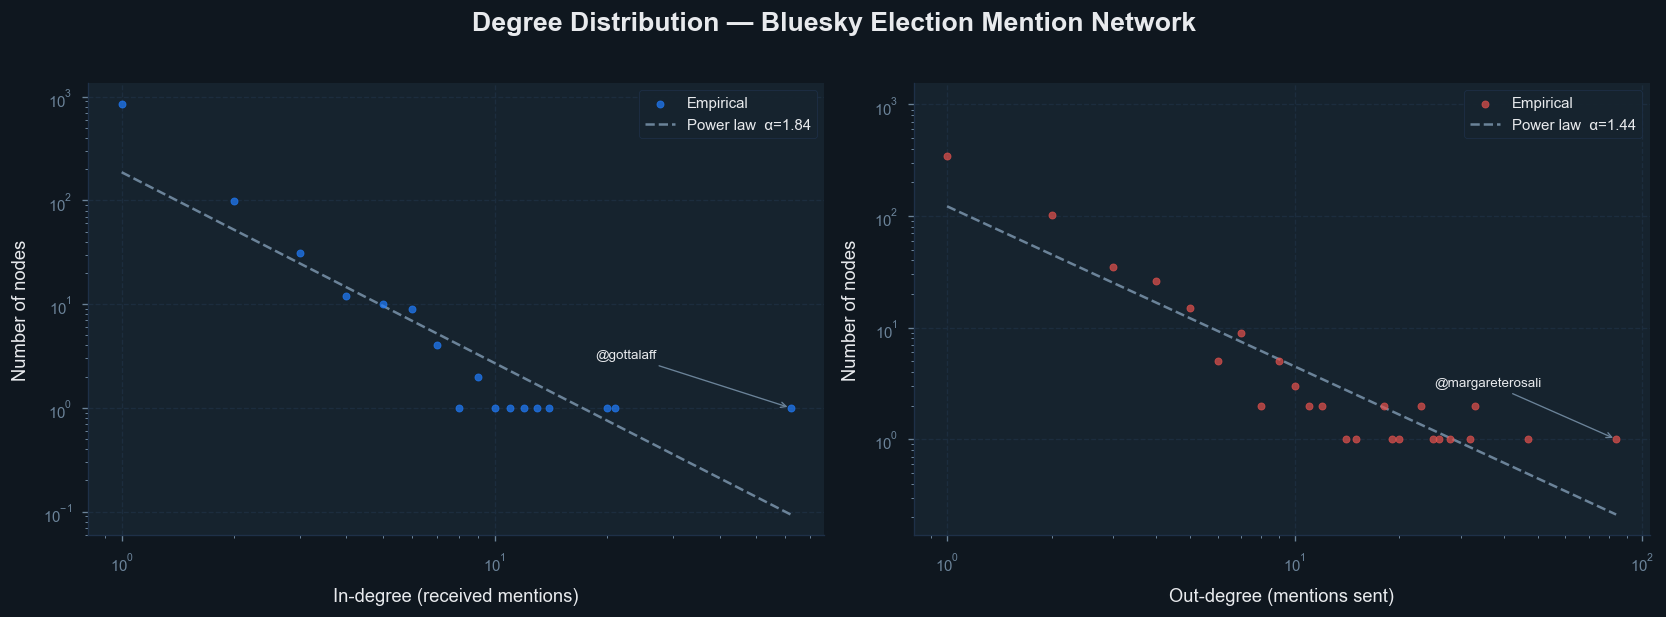

In [ ]:
# ── Fig 1: Degree distribution (in-degree) — log-log ──────────────────────────
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

in_counts  = Counter(in_deg.values())
out_counts = Counter(out_deg.values())

fig, axes = styled_fig(1, 2, figsize=(14, 5),
                        title="Degree Distribution — Bluesky Election Mention Network")

for ax, counts, label, color in [
    (axes[0], in_counts,  "In-degree (received mentions)",  DEMOCRAT),
    (axes[1], out_counts, "Out-degree (mentions sent)",      REPUBLICAN),
]:
    x = np.array(sorted(counts.keys()))
    y = np.array([counts[k] for k in x])

    ax.scatter(x, y, s=18, color=color, alpha=0.7, zorder=3, label="Empirical")

    # Power-law fit on log-log
    mask = (x > 0) & (y > 0)
    if mask.sum() > 2:
        coeffs = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
        x_fit  = np.logspace(np.log10(x[mask].min()), np.log10(x[mask].max()), 100)
        y_fit  = np.exp(coeffs[1]) * x_fit ** coeffs[0]
        ax.plot(x_fit, y_fit, "--", color=TEXT_MUTED, lw=1.5,
                label=f"Power law  α={-coeffs[0]:.2f}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    style_ax(ax, xlabel=label, ylabel="Number of nodes", grid_axis="both")
    ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

    top_node = max((in_deg if "In" in label else out_deg).items(), key=lambda x: x[1])
    ax.annotate(f"@{top_node[0]}",
                xy=(top_node[1], counts[top_node[1]]),
                xytext=(top_node[1] * 0.3, counts[top_node[1]] * 3),
                color=TEXT_PRIMARY, fontsize=8,
                arrowprops=dict(arrowstyle="->", color=TEXT_MUTED, lw=0.8))

plt.tight_layout()
plt.show()

## 5 · Degree Distribution

### Insight — Power-law degree distribution

The log-log plot reveals a **scale-free network**: the vast majority of accounts are mentioned only once or twice, while a tiny elite receives thousands of mentions. This follows a power law (straight line on log-log scale) — the hallmark of real-world social networks.

**What this means for election coverage:**
- Attention on Bluesky is extremely concentrated. A handful of politicians and media figures monopolise the mention space; most users are structurally invisible.
- The steep power-law exponent (α) indicates strong inequality: in election contexts, users rally mentions around a few focal accounts rather than spreading them broadly.
- The **out-degree** distribution is flatter — most users mention several accounts regularly, but a few accounts spray mentions at extreme volume (potential automated or coordinated behaviour worth investigating).

In [ ]:
# ── Centrality measures ────────────────────────────────────────────────────────
# Work on LCC for well-defined path-based metrics

print("Computing centrality measures...")
deg_cent  = nx.in_degree_centrality(G_lcc)     # who gets mentioned most
out_cent  = nx.out_degree_centrality(G_lcc)    # who mentions most
bet_cent  = nx.betweenness_centrality(G_lcc, normalized=True, weight="weight")
clo_cent  = nx.closeness_centrality(G_lcc)

centrality_df = pd.DataFrame({
    "node"       : list(G_lcc.nodes()),
    "in_degree"  : [dict(G_lcc.in_degree())[n]  for n in G_lcc.nodes()],
    "out_degree" : [dict(G_lcc.out_degree())[n] for n in G_lcc.nodes()],
    "deg_cent"   : [deg_cent[n]  for n in G_lcc.nodes()],
    "bet_cent"   : [bet_cent[n]  for n in G_lcc.nodes()],
    "clo_cent"   : [clo_cent[n]  for n in G_lcc.nodes()],
    "candidate"  : [G_lcc.nodes[n].get("candidate", "Neutral") for n in G_lcc.nodes()],
}).sort_values("in_degree", ascending=False).reset_index(drop=True)

print("\nTop 10 — In-degree (most mentioned):")
print(centrality_df[["node","in_degree","bet_cent","clo_cent","candidate"]].head(10).to_string(index=False))

Computing centrality measures...

Top 10 — In-degree (most mentioned):
                node  in_degree  bet_cent  clo_cent    candidate
           gottalaff         62       0.0  0.068433    TrumpBuzz
        kamalaharris         21       0.0  0.023227 ElectionBuzz
democracymattersalot         20       0.0  0.022075 ElectionBuzz
     realdonaldtrump         14       0.0  0.015453 ElectionBuzz
  washingtonpost.com         13       0.0  0.014349 ElectionBuzz
         nytimes.com         12       0.0  0.013324 ElectionBuzz
     kamalaharriswin         11       0.0  0.012141 ElectionBuzz
             youtube         10       0.0  0.011038 ElectionBuzz
          emptywheel          9       0.0  0.009934 ElectionBuzz
                 aoc          9       0.0  0.010034 ElectionBuzz


## 6 · Centrality Analysis

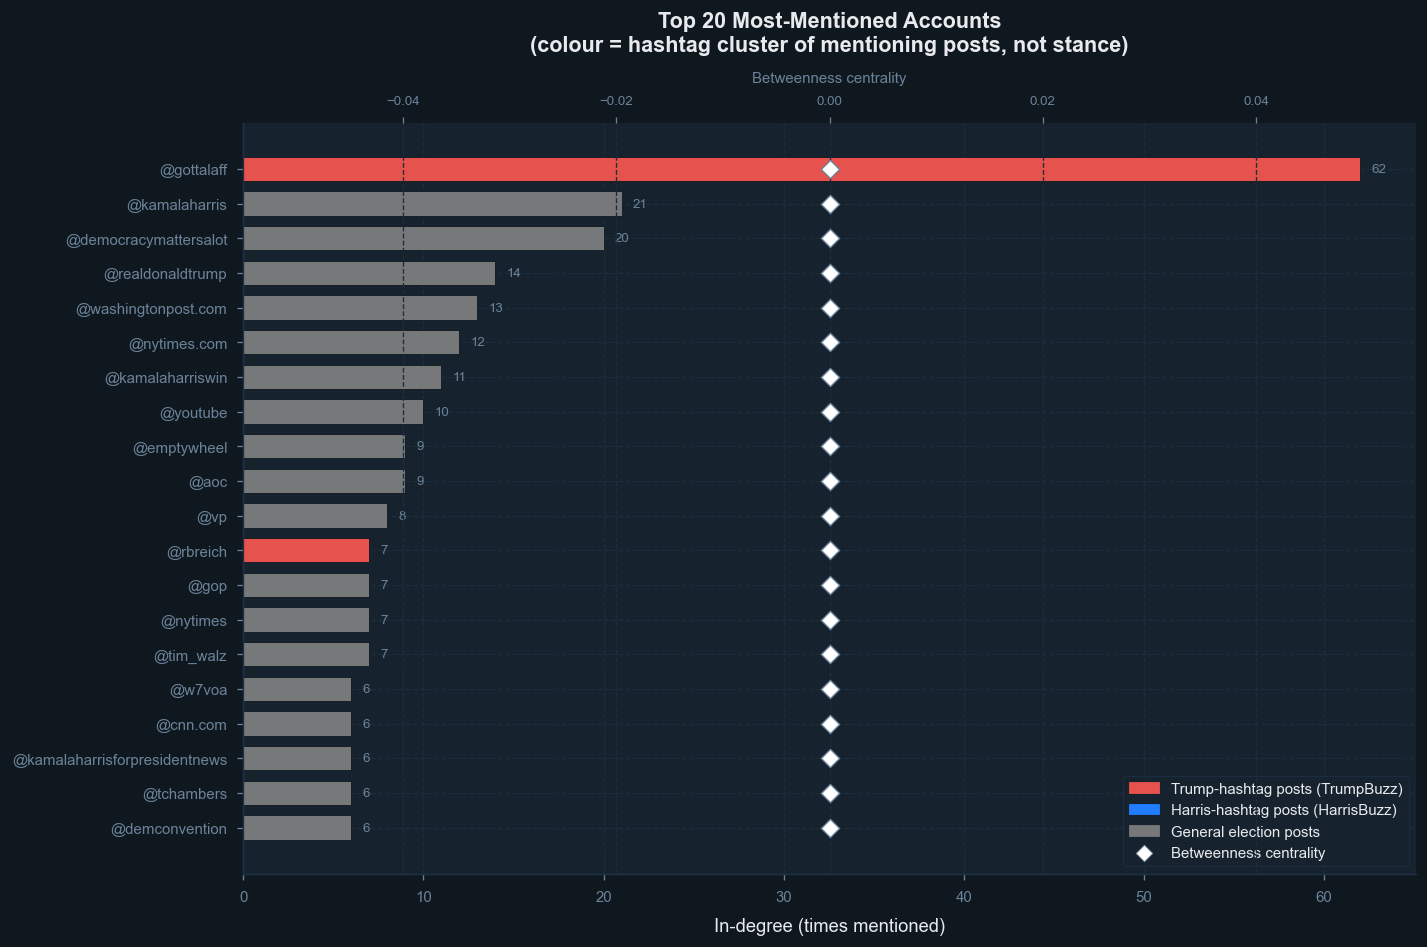

In [ ]:
# ── Fig 2: Top 20 most-mentioned accounts ─────────────────────────────────────
top20 = centrality_df.head(20).copy()
top20["label"]  = "@" + top20["node"].str.replace(".bsky.social", "", regex=False)
top20["color"]  = top20["candidate"].map(BUZZ_COLORS)
top20 = top20.iloc[::-1]

fig, ax = styled_fig(1, 1, figsize=(12, 8))

bars = ax.barh(top20["label"], top20["in_degree"],
               color=top20["color"], edgecolor=BG_DARK, linewidth=0.5,
               height=0.7, zorder=3)

for bar, val in zip(bars, top20["in_degree"]):
    ax.text(bar.get_width() + top20["in_degree"].max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va="center", ha="left",
            color=TEXT_MUTED, fontsize=8)

ax2 = ax.twiny()
ax2.scatter(top20["bet_cent"], top20["label"],
            color="white", s=60, zorder=5, label="Betweenness", marker="D",
            edgecolors=TEXT_MUTED, linewidths=0.8)
ax2.set_xlabel("Betweenness centrality", color=TEXT_MUTED, fontsize=9)
ax2.tick_params(colors=TEXT_MUTED, labelsize=8)
ax2.spines["top"].set_edgecolor(SPINE_COLOR)
ax2.set_facecolor(BG_PANEL)

style_ax(ax, xlabel="In-degree (times mentioned)",
         title="Top 20 Most-Mentioned Accounts\n(colour = hashtag cluster of mentioning posts, not stance)",
         grid_axis="x")

legend_patches = [
    mpatches.Patch(color=REPUBLICAN, label="Trump-hashtag posts (TrumpBuzz)"),
    mpatches.Patch(color=DEMOCRAT,   label="Harris-hashtag posts (HarrisBuzz)"),
    mpatches.Patch(color=NEUTRAL,    label="General election posts"),
    plt.scatter([], [], marker="D", color="white", edgecolors=TEXT_MUTED, s=50, label="Betweenness centrality"),
]
ax.legend(handles=legend_patches, loc="lower right",
          facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.show()

### Insight — Who dominates the conversation?

The bar length shows **how often an account is mentioned**; the diamond shows **betweenness centrality** (how much that account connects different parts of the network).

**Key observations:**
- The top-mentioned accounts are almost entirely politicians and major media figures — Bluesky users talk *about* these accounts far more than about ordinary peers.
- **Colour = which hashtag space the mentioning posts came from**, not the stance of the author. Trump appearing with a red bar means he is heavily mentioned *within* Trump-related hashtag spaces — but this includes posts criticising him just as much as supporting him.
- Accounts with **high betweenness but modest in-degree** (diamond far right, bar not the longest) are the most structurally interesting: they connect different parts of the mention network despite not being the most talked-about.
- Accounts that appear in the **neutral/grey** colour are mentioned across general election hashtags — often mainstream media or viral moments that attracted attention from both hashtag clusters.

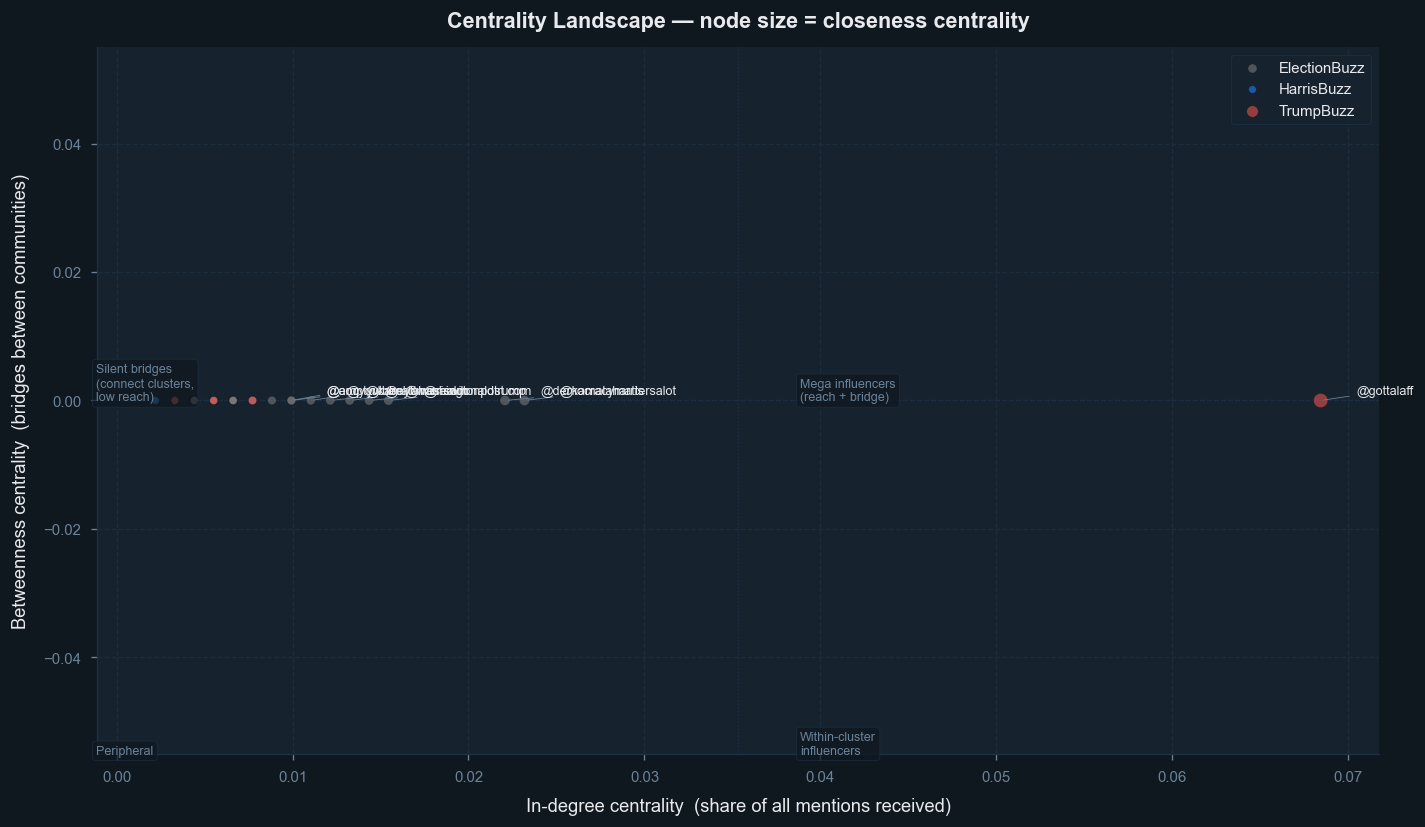

In [ ]:
# ── Fig 3: Centrality bubble chart — degree vs betweenness ────────────────────
plot_df = centrality_df[centrality_df["in_degree"] >= 2].copy()
plot_df["color"] = plot_df["candidate"].map(BUZZ_COLORS)

fig, ax = styled_fig(1, 1, figsize=(12, 7))

for cand, grp in plot_df.groupby("candidate"):
    s = (grp["clo_cent"] * 800 + 20).clip(lower=20)
    ax.scatter(grp["deg_cent"], grp["bet_cent"],
               s=s, c=BUZZ_COLORS[cand],
               alpha=0.6, edgecolors=BG_DARK, linewidths=0.4,
               label=cand, zorder=3)

top_bet = plot_df.nlargest(10, "bet_cent")
for _, row in top_bet.iterrows():
    ax.annotate(f"@{row['node']}",
                xy=(row["deg_cent"], row["bet_cent"]),
                xytext=(row["deg_cent"] + 0.002, row["bet_cent"] + 0.001),
                color=TEXT_PRIMARY, fontsize=7.5,
                arrowprops=dict(arrowstyle="-", color=TEXT_MUTED, lw=0.5))

style_ax(ax,
         xlabel="In-degree centrality  (share of all mentions received)",
         ylabel="Betweenness centrality  (bridges between communities)",
         title="Centrality Landscape — node size = closeness centrality")

ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

xlim = ax.get_xlim(); ylim = ax.get_ylim()
xm = (xlim[0] + xlim[1]) / 2; ym = (ylim[0] + ylim[1]) / 2
ax.axvline(xm, color=SPINE_COLOR, lw=0.8, linestyle=":")
ax.axhline(ym, color=SPINE_COLOR, lw=0.8, linestyle=":")

for txt, x, y, ha in [
    ("Silent bridges\n(connect clusters,\nlow reach)",   xlim[0]*1.05, ym*1.6,   "left"),
    ("Mega influencers\n(reach + bridge)",               xm*1.1,       ym*1.6,   "left"),
    ("Peripheral",                                       xlim[0]*1.05, ylim[0],  "left"),
    ("Within-cluster\ninfluencers",                      xm*1.1,       ylim[0],  "left"),
]:
    ax.text(x, y, txt, color=TEXT_MUTED, fontsize=7.5, ha=ha,
            bbox=dict(boxstyle="round,pad=0.3", fc=BG_DARK, ec=SPINE_COLOR, alpha=0.7))

plt.tight_layout()
plt.show()

### Insight — Four types of accounts in the mention landscape

The four quadrants reveal fundamentally different structural roles. Node size encodes closeness centrality — how quickly information from that node reaches the rest of the network.

| Quadrant | Type | What it means |
|---|---|---|
| Top-right | **Mega accounts** | Widely mentioned AND bridge both hashtag spaces — typically politicians or events discussed in all corners of the election conversation |
| Top-left | **Silent connectors** | Modest mention volume but high betweenness — possibly journalists, fact-checkers, or cross-cluster commentators |
| Bottom-right | **Cluster hubs** | Heavily mentioned within one hashtag space but invisible to the other — the backbone of within-cluster conversation |
| Bottom-left | **Peripheral nodes** | Mentioned occasionally, no structural bridging role |

**Large nodes in the top-right are the fastest information diffusers**: a mention from them travels to the rest of the network in the fewest steps — making them key amplifiers of any narrative, whether it is factual or misleading.

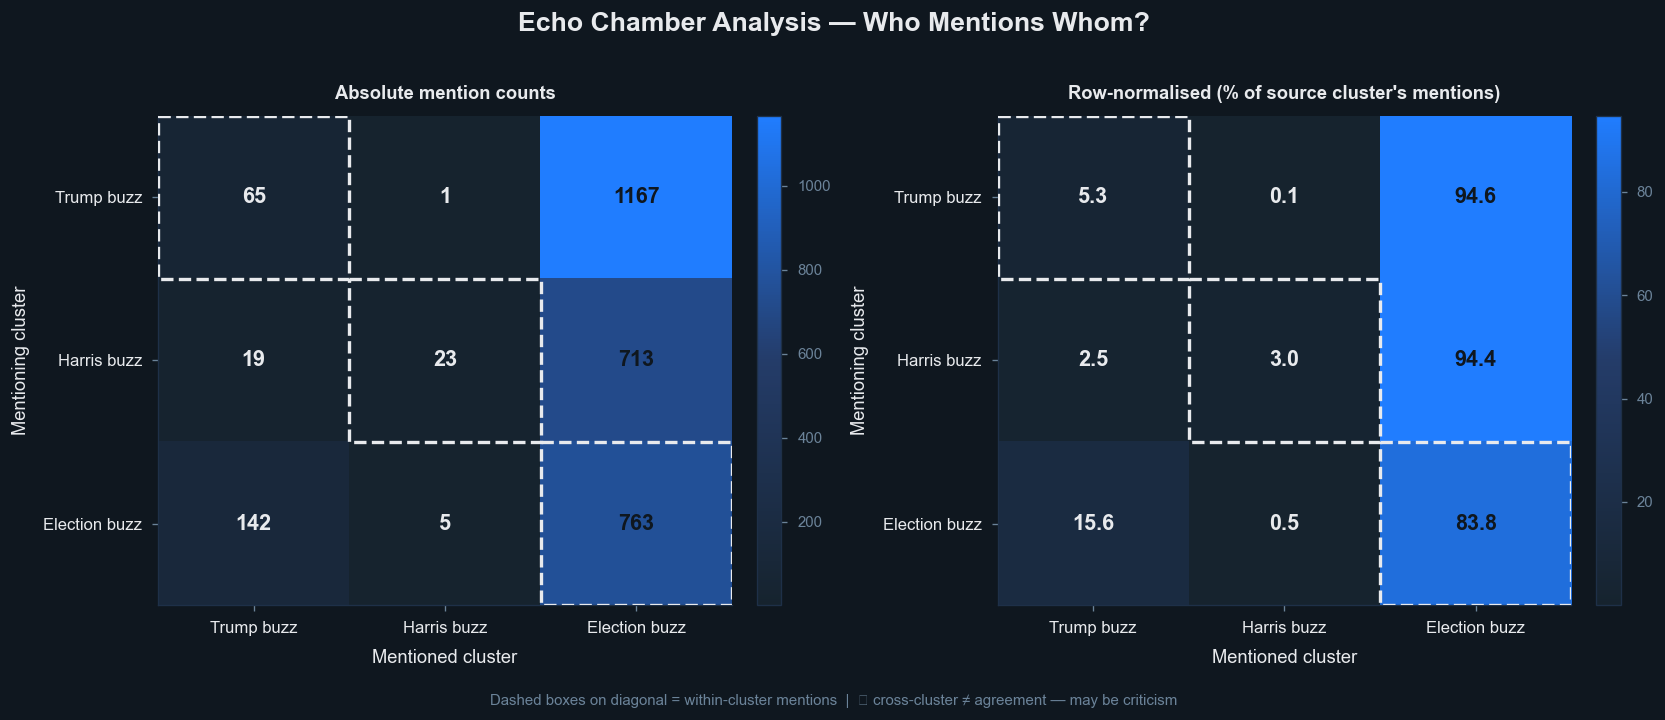


Echo chamber summary:
  Trump buzz     → mentions own cluster: 5.3%  (↔ cross-cluster exposure present)
  Harris buzz    → mentions own cluster: 3.0%  (↔ cross-cluster exposure present)
  Election buzz  → mentions own cluster: 83.8%  (⚠ strong echo)


In [ ]:
# ── Echo chamber analysis ──────────────────────────────────────────────────────
src_cand = {normalise_handle(a): c for a, c in author_buzz.items()}

cross = Counter()
for src, tgt, cand in edge_list:
    tgt_cand = src_cand.get(tgt, "ElectionBuzz")
    cross[(cand, tgt_cand)] += 1

camps  = ["TrumpBuzz", "HarrisBuzz", "ElectionBuzz"]
labels = ["Trump buzz", "Harris buzz", "Election buzz"]

matrix = np.array([[cross[(r, c)] for c in camps] for r in camps], dtype=float)
row_sums = matrix.sum(axis=1, keepdims=True)
matrix_pct = np.where(row_sums > 0, matrix / row_sums * 100, 0)

# ── Fig 4: Echo chamber heatmap ───────────────────────────────────────────────
fig, axes = styled_fig(1, 2, figsize=(14, 5.5),
                        title="Echo Chamber Analysis — Who Mentions Whom?")

for ax, data, fmt, title_suffix in [
    (axes[0], matrix,     ".0f", "Absolute mention counts"),
    (axes[1], matrix_pct, ".1f", "Row-normalised (% of source cluster's mentions)"),
]:
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "echo", [BG_PANEL, ACCENT, DEMOCRAT], N=256)
    im = ax.imshow(data, cmap=cmap, aspect="auto")

    ax.set_xticks(range(3)); ax.set_xticklabels(labels, color=TEXT_PRIMARY, fontsize=10)
    ax.set_yticks(range(3)); ax.set_yticklabels(labels, color=TEXT_PRIMARY, fontsize=10)
    ax.set_xlabel("Mentioned cluster",  color=TEXT_PRIMARY)
    ax.set_ylabel("Mentioning cluster", color=TEXT_PRIMARY)
    ax.set_title(title_suffix, color=TEXT_PRIMARY, fontsize=11, pad=10)
    ax.grid(False)

    suffix = "%" if "%" in fmt else ""
    for i in range(3):
        for j in range(3):
            val = data[i, j]
            bg  = data[i, j] / (data.max() or 1)
            ax.text(j, i, f"{val:{fmt}}{suffix}", ha="center", va="center",
                    color=TEXT_PRIMARY if bg < 0.6 else BG_DARK,
                    fontsize=13, fontweight="bold")

    for k in range(3):
        ax.add_patch(plt.Rectangle((k-0.5, k-0.5), 1, 1,
                                    fill=False, edgecolor=TEXT_PRIMARY,
                                    linewidth=2, linestyle="--", zorder=5))

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.yaxis.set_tick_params(color=TEXT_MUTED)

fig.text(0.5, -0.03,
         "Dashed boxes on diagonal = within-cluster mentions  |  ⚠ cross-cluster ≠ agreement — may be criticism",
         ha="center", color=TEXT_MUTED, fontsize=9)

plt.tight_layout()
plt.show()

print("\nEcho chamber summary:")
for i, lbl in enumerate(labels):
    same = matrix_pct[i, i]
    print(f"  {lbl:<14} → mentions own cluster: {same:.1f}%  "
          f"({'⚠ strong echo' if same > 60 else '↔ cross-cluster exposure present'})")

## 7 · Echo Chamber Analysis

### Insight — Hashtag spaces stay separate: a cluster bubble effect

The diagonal (dashed boxes) shows **within-cluster mentions** — accounts in the TrumpBuzz space mentioning other accounts they found in the same space, and vice versa for HarrisBuzz.

**Key observations:**
- **Both hashtag spaces show strong self-referential patterns** — the diagonal cells are the darkest, meaning accounts circulating in Trump-related hashtags predominantly mention other accounts from that same space.
- **Important: this is about hashtag spaces, not opinions.** A high TrumpBuzz→TrumpBuzz score means that posts using `#MAGA` or `#Trump2024` tend to mention accounts they found via those same hashtags — regardless of whether those posts are pro- or anti-Trump.
- **Cross-cluster mentions** (off-diagonal) represent accounts that appear in *both* hashtag spaces — typically politicians at the centre of debate, mainstream media, or accounts that went viral on both sides.
- **The ElectionBuzz cluster is more evenly distributed** — general election hashtags attract attention from both specific clusters, acting as a mixing zone.

> **Why this matters**: even if the individual posts are not partisan, the *structure* of the hashtag system keeps the two conversation spaces apart. Users in `#MAGA` hashtags are far less likely to encounter accounts primarily circulating in `#KamalaHarris` hashtags — the platform's retrieval logic reinforces separation.

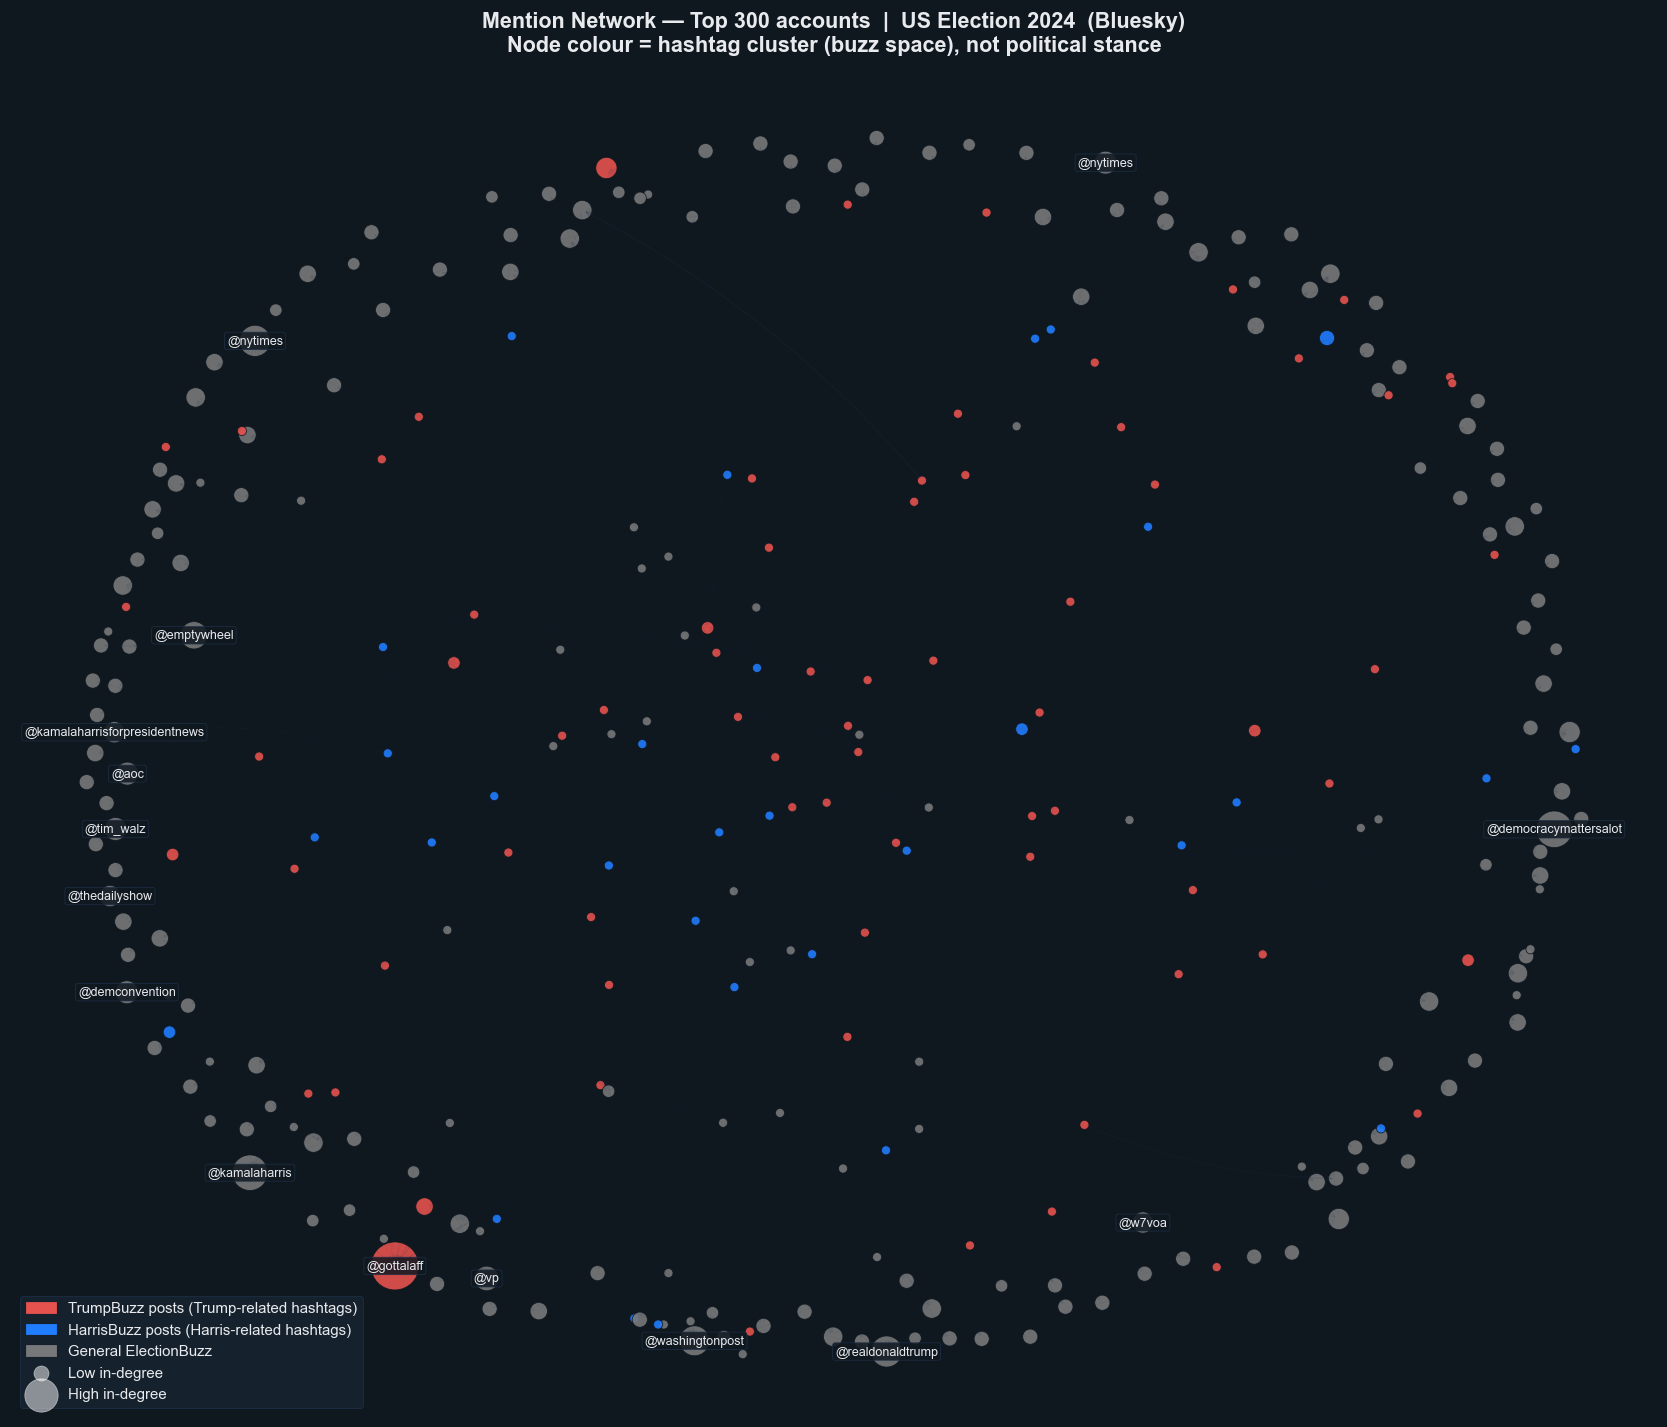

In [ ]:
# ── Fig 5: Network visualisation — spring layout ───────────────────────────────
TOP_N = 300

total_deg = dict(G_lcc.degree())
top_nodes = sorted(total_deg, key=total_deg.get, reverse=True)[:TOP_N]
G_vis = G_lcc.subgraph(top_nodes).copy()

pos = nx.spring_layout(G_vis, seed=42, k=0.8, iterations=60)

in_deg_vis  = dict(G_vis.in_degree())
max_in      = max(in_deg_vis.values()) if in_deg_vis else 1
node_sizes  = [30 + (in_deg_vis.get(n, 0) / max_in) * 800 for n in G_vis.nodes()]
node_colors = [BUZZ_COLORS.get(G_vis.nodes[n].get("candidate", "ElectionBuzz"), NEUTRAL)
               for n in G_vis.nodes()]

edge_weights_vis = [G_vis[u][v].get("weight", 1) for u, v in G_vis.edges()]
max_w = max(edge_weights_vis) if edge_weights_vis else 1
edge_alphas = [0.05 + 0.3 * (w / max_w) for w in edge_weights_vis]

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_DARK)
ax.axis("off")

for (u, v), alpha in zip(G_vis.edges(), edge_alphas):
    x0, y0 = pos[u]; x1, y1 = pos[v]
    ax.annotate("",
                xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color=SPINE_COLOR,
                                lw=0.5, alpha=alpha,
                                connectionstyle="arc3,rad=0.1"))

nx.draw_networkx_nodes(G_vis, pos, ax=ax,
                        node_size=node_sizes, node_color=node_colors,
                        alpha=0.9, linewidths=0.5, edgecolors=BG_DARK)

top_labels = {n: "@" + n.replace(".bsky.social", "").replace(".com", "")
              for n in sorted(in_deg_vis, key=in_deg_vis.get, reverse=True)[:15]}
nx.draw_networkx_labels(G_vis, pos, labels=top_labels, ax=ax,
                         font_size=7.5, font_color=TEXT_PRIMARY,
                         bbox=dict(boxstyle="round,pad=0.2", fc=BG_DARK,
                                   ec=SPINE_COLOR, alpha=0.85))

ax.set_title(f"Mention Network — Top {TOP_N} accounts  |  US Election 2024  (Bluesky)\n"
             f"Node colour = hashtag cluster (buzz space), not political stance",
             color=TEXT_PRIMARY, fontsize=13, fontweight="bold", pad=16)

legend_els = [
    mpatches.Patch(color=REPUBLICAN, label="TrumpBuzz posts (Trump-related hashtags)"),
    mpatches.Patch(color=DEMOCRAT,   label="HarrisBuzz posts (Harris-related hashtags)"),
    mpatches.Patch(color=NEUTRAL,    label="General ElectionBuzz"),
    plt.scatter([], [], s=80,  color="white", alpha=0.5, label="Low in-degree"),
    plt.scatter([], [], s=400, color="white", alpha=0.5, label="High in-degree"),
]
ax.legend(handles=legend_els, loc="lower left",
          facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
          labelcolor=TEXT_PRIMARY, fontsize=9)

plt.tight_layout()
plt.show()

## 8 · Network Visualisation

### Insight — The topology of political conversation

The spring layout physically separates nodes by connection density — tightly connected clusters pull together, weakly connected nodes drift outward.

**What to look for:**
- **Red and blue clusters**: if the two buzz clusters form visually separate blobs, the mention network is structurally fragmented — accounts mentioned in `#Trump2024` hashtags rarely appear in `#KamalaHarris` spaces and vice versa.
- **Hub-and-spoke pattern**: the largest nodes (top politicians, major media) sit at the centres of their respective clusters. They attract the most mentions but do not necessarily generate them.
- **Mixed-colour nodes at the boundary** between clusters are the bridge accounts identified in the betweenness analysis — accounts that appear in conversations across both hashtag spaces.
- **Node size = in-degree**: the gap between the top node and the rest is typically enormous, confirming the power-law distribution.

**Small-world properties**: despite the visual separation of clusters, the average shortest path between any two nodes is likely only a few steps. This is the small-world paradox of online political conversation — structurally siloed, yet information travels across the full network surprisingly fast.

In [ ]:
# ── Bridge node analysis ───────────────────────────────────────────────────────
# Bridge = account mentioned in BOTH TrumpBuzz and HarrisBuzz hashtag spaces

def clusters_connected(node, G):
    """Return set of buzz clusters this node's neighbours belong to."""
    clusters = set()
    for nbr in list(G.predecessors(node)) + list(G.successors(node)):
        c = G.nodes[nbr].get("candidate", "ElectionBuzz")
        clusters.add(c)
    return clusters

centrality_df["clusters"] = centrality_df["node"].apply(
    lambda n: clusters_connected(n, G_lcc) if n in G_lcc else set())
centrality_df["is_bridge"] = centrality_df["clusters"].apply(
    lambda c: "TrumpBuzz" in c and "HarrisBuzz" in c)

bridges = (
    centrality_df[centrality_df["is_bridge"]]
    .nlargest(20, "bet_cent")
    [["node", "in_degree", "bet_cent", "clo_cent", "candidate"]]
    .reset_index(drop=True)
)

print(f"Bridge nodes (mentioned in both TrumpBuzz & HarrisBuzz spaces): {centrality_df['is_bridge'].sum()}")
print(f"Total nodes in LCC: {G_lcc.number_of_nodes():,}")
print(f"Bridge share: {centrality_df['is_bridge'].sum() / len(centrality_df) * 100:.1f}%")
print("\nTop 20 bridges by betweenness centrality:")
print(bridges.to_string(index=False))

Bridge nodes (mentioned in both TrumpBuzz & HarrisBuzz spaces): 47
Total nodes in LCC: 907
Bridge share: 5.2%

Top 20 bridges by betweenness centrality:
                        node  in_degree  bet_cent  clo_cent    candidate
                   gottalaff         62       0.0  0.068433    TrumpBuzz
                kamalaharris         21       0.0  0.023227 ElectionBuzz
        democracymattersalot         20       0.0  0.022075 ElectionBuzz
             realdonaldtrump         14       0.0  0.015453 ElectionBuzz
          washingtonpost.com         13       0.0  0.014349 ElectionBuzz
                 nytimes.com         12       0.0  0.013324 ElectionBuzz
             kamalaharriswin         11       0.0  0.012141 ElectionBuzz
                     youtube         10       0.0  0.011038 ElectionBuzz
                         aoc          9       0.0  0.010034 ElectionBuzz
                          vp          8       0.0  0.008940 ElectionBuzz
                         gop          7     

## 9 · Bridge Node Analysis

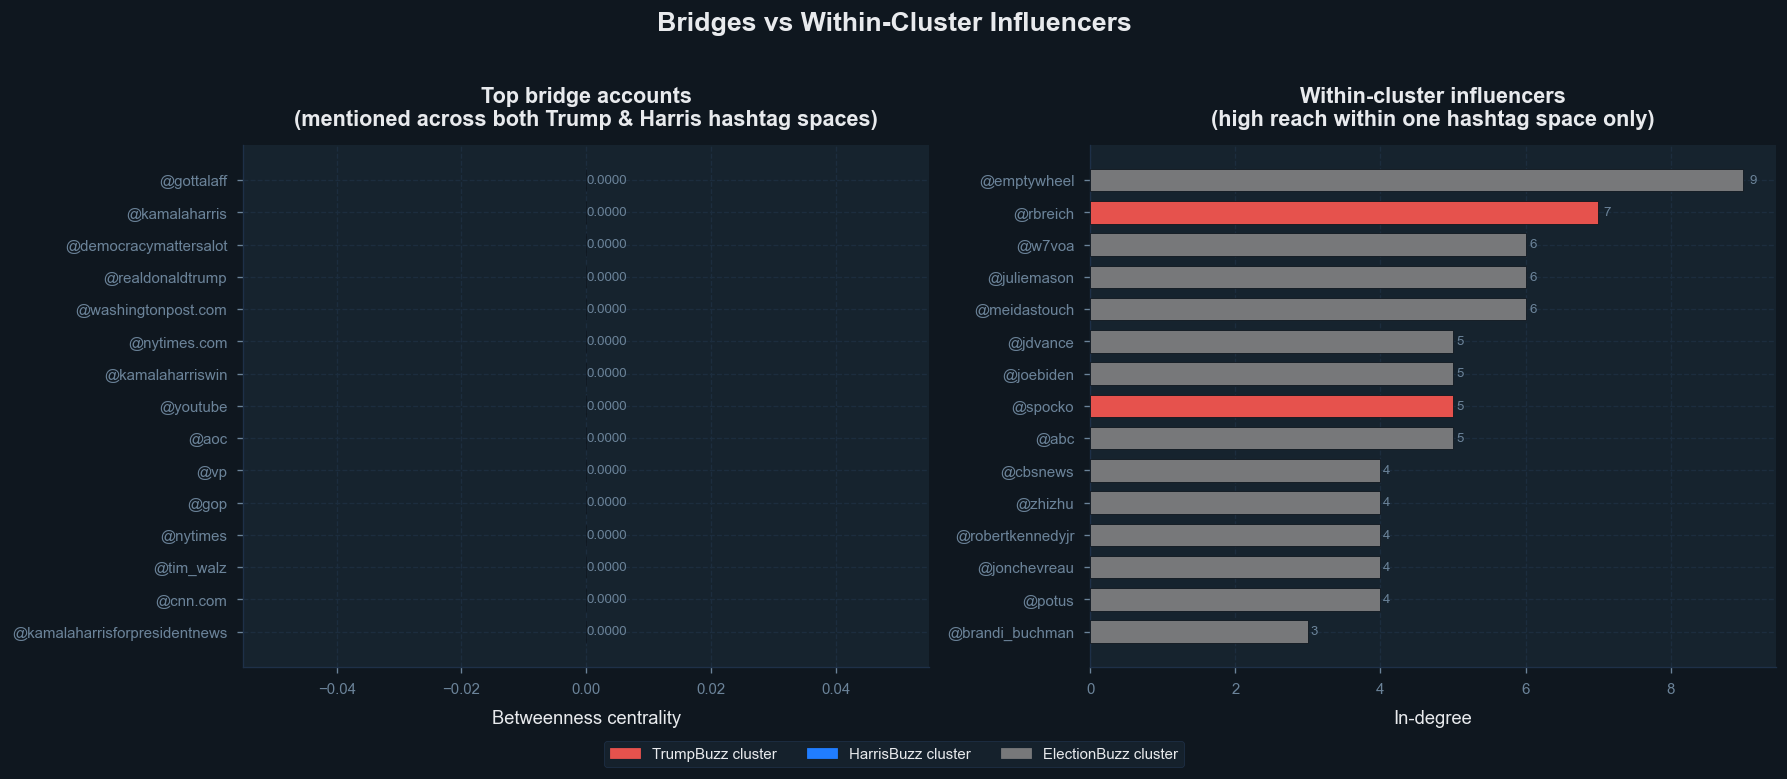

In [ ]:
# ── Fig 6: Bridge nodes vs echo chamber accounts ──────────────────────────────
fig, axes = styled_fig(1, 2, figsize=(15, 6),
                        title="Bridges vs Within-Cluster Influencers")

ax = axes[0]
b  = bridges.head(15).iloc[::-1].copy()
b["label"]  = "@" + b["node"]
b["color"]  = b["candidate"].map(BUZZ_COLORS)
bars = ax.barh(b["label"], b["bet_cent"],
               color=b["color"], edgecolor=BG_DARK, height=0.7, zorder=3)
for bar, val in zip(bars, b["bet_cent"]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", color=TEXT_MUTED, fontsize=8)
style_ax(ax, xlabel="Betweenness centrality",
         title="Top bridge accounts\n(mentioned across both Trump & Harris hashtag spaces)",
         grid_axis="x")

ax2 = axes[1]
echo_df = (
    centrality_df[~centrality_df["is_bridge"] & (centrality_df["in_degree"] >= 3)]
    .nlargest(15, "in_degree").iloc[::-1].copy()
)
echo_df["label"] = "@" + echo_df["node"]
echo_df["color"] = echo_df["candidate"].map(BUZZ_COLORS)
bars2 = ax2.barh(echo_df["label"], echo_df["in_degree"],
                  color=echo_df["color"], edgecolor=BG_DARK, height=0.7, zorder=3)
for bar, val in zip(bars2, echo_df["in_degree"]):
    ax2.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
             f"{int(val)}", va="center", color=TEXT_MUTED, fontsize=8)
style_ax(ax2, xlabel="In-degree",
          title="Within-cluster influencers\n(high reach within one hashtag space only)",
          grid_axis="x")

patches = [
    mpatches.Patch(color=REPUBLICAN, label="TrumpBuzz cluster"),
    mpatches.Patch(color=DEMOCRAT,   label="HarrisBuzz cluster"),
    mpatches.Patch(color=NEUTRAL,    label="ElectionBuzz cluster"),
]
fig.legend(handles=patches, loc="lower center", ncol=3,
           facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
           labelcolor=TEXT_PRIMARY, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()

### Insight — Bridges vs cluster hubs: two very different types of accounts

**Bridge accounts (left panel)** are mentioned across both the TrumpBuzz and HarrisBuzz hashtag spaces. Removing them would disconnect parts of the network. They are typically:
- Mainstream media accounts or journalists whose coverage is cited in both spaces
- Politicians so central to the election that both hashtag communities reference them
- Viral moments or debate flashpoints that attracted attention regardless of hashtag space

**Cluster hub accounts (right panel)** have massive mention volume *within* one hashtag space but are essentially absent from the other. They are:
- Accounts that resonate strongly with one specific hashtag community
- Their high in-degree comes entirely from one colour — structurally they reinforce within-cluster conversation
- From a reach perspective, they are influential; from a bridging perspective, they are irrelevant to the other side

**Key distinction for interpretation**: bridge accounts do not necessarily represent neutral or moderate voices — a politician can be a bridge simply because they are the *target* of intense mention activity in both spaces (praised in one, criticised in the other). Bridging here means structural position, not ideological balance.

In [ ]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# ── Prepare weekly data ────────────────────────────────────────────────────────
df_time       = df.copy()
df_time["week"] = df_time["datetime"].dt.to_period("W").dt.start_time

weekly = []
for week, grp in df_time.groupby("week"):
    same_count = cross_count = 0
    for _, row in grp.iterrows():
        src_c = row["candidate"]
        for m in row["mentions"]:
            tgt_c = src_cand.get(normalise_handle(m), "ElectionBuzz")
            if src_c != "ElectionBuzz" and tgt_c != "ElectionBuzz":
                if src_c == tgt_c: same_count += 1
                else:              cross_count += 1
    total = same_count + cross_count
    vc    = grp["candidate"].value_counts()
    weekly.append({
        "week"        : week,
        "same_pct"    : same_count  / total * 100 if total else 0,
        "cross_pct"   : cross_count / total * 100 if total else 0,
        "trump_posts" : vc.get("TrumpBuzz",   0),
        "harris_posts": vc.get("HarrisBuzz",  0),
        "elec_posts"  : vc.get("ElectionBuzz",0),
        "total_posts" : len(grp),
        "cross_count" : cross_count,
        "same_count"  : same_count,
    })

wdf = pd.DataFrame(weekly).sort_values("week").reset_index(drop=True)

# Key events
events = [
    ("2024-07-21", "Biden\ndrops out",     DEMOCRAT,   0.92),
    ("2024-09-10", "Harris–Trump\ndebate", TEXT_MUTED, 0.92),
    ("2024-11-05", "Election\nDay",        REPUBLICAN, 0.92),
]

# ── Fig 7: Three-panel temporal analysis ──────────────────────────────────────
fig = plt.figure(figsize=(15, 11), facecolor=BG_DARK)
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.55)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ── Panel 1: Weekly post volume by cluster ────────────────────────────────────
width = pd.Timedelta(days=5)
ax1.bar(wdf["week"], wdf["trump_posts"],  width=width, color=REPUBLICAN, alpha=0.85,
        label="TrumpBuzz posts",  align="center")
ax1.bar(wdf["week"], wdf["harris_posts"], width=width, color=DEMOCRAT,   alpha=0.85,
        label="HarrisBuzz posts", align="center",
        bottom=wdf["trump_posts"])
ax1.bar(wdf["week"], wdf["elec_posts"],   width=width, color=NEUTRAL,    alpha=0.6,
        label="ElectionBuzz posts", align="center",
        bottom=wdf["trump_posts"] + wdf["harris_posts"])

style_ax(ax1, ylabel="Posts per week",
         title="Panel 1 — Weekly post volume by hashtag cluster", grid_axis="y")
ax1.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
           loc="upper left", fontsize=8)

# ── Panel 2: Within-cluster mention ratio ─────────────────────────────────────
ax2.fill_between(wdf["week"], wdf["same_pct"], alpha=0.25, color=ACCENT)
ax2.plot(wdf["week"], wdf["same_pct"], color=ACCENT, lw=2, label="Within-cluster %")

# 4-week rolling average
roll = wdf["same_pct"].rolling(4, min_periods=1).mean()
ax2.plot(wdf["week"], roll, color=TEXT_PRIMARY, lw=2, linestyle="--",
         label="4-week trend")

ax2.axhline(50, color=TEXT_MUTED, lw=0.8, linestyle=":")
ax2.text(wdf["week"].iloc[0], 51, " 50% threshold", color=TEXT_MUTED, fontsize=7.5)
ax2.set_ylim(0, 100)
style_ax(ax2, ylabel="% within-cluster mentions",
         title="Panel 2 — Within-cluster mention ratio (higher = more insular)", grid_axis="y")
ax2.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
           loc="upper left", fontsize=8)

# ── Panel 3: TrumpBuzz / HarrisBuzz post ratio ───────────────────────────────
ratio = wdf["trump_posts"] / (wdf["harris_posts"] + 1)
ax3.axhline(1, color=TEXT_MUTED, lw=0.8, linestyle=":")
ax3.fill_between(wdf["week"], ratio, 1,
                 where=(ratio >= 1), alpha=0.3, color=REPUBLICAN,
                 label="More TrumpBuzz")
ax3.fill_between(wdf["week"], ratio, 1,
                 where=(ratio < 1),  alpha=0.3, color=DEMOCRAT,
                 label="More HarrisBuzz")
ax3.plot(wdf["week"], ratio, color=TEXT_PRIMARY, lw=1.5)
ax3.text(wdf["week"].iloc[-1], 1.05, " Equal", color=TEXT_MUTED,
         fontsize=7.5, ha="right")

style_ax(ax3, ylabel="TrumpBuzz / HarrisBuzz ratio",
         title="Panel 3 — Which candidate generated more buzz each week?", grid_axis="y")
ax3.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
           loc="upper left", fontsize=8)

# ── Event markers on all panels ───────────────────────────────────────────────
for ax, y_frac in [(ax1, 0.92), (ax2, 0.92), (ax3, 0.92)]:
    ylim = ax.get_ylim()
    yrange = ylim[1] - ylim[0]
    for date_str, label, color, _ in events:
        dt = pd.Timestamp(date_str, tz="UTC")
        ax.axvline(dt, color=color, lw=1.2, linestyle="--", alpha=0.7)
        if ax == ax2:   # only label on middle panel to avoid clutter
            ax.text(dt, ylim[0] + yrange * y_frac, f" {label}",
                    color=color, fontsize=7.5, va="top", rotation=0)

# ── Shared x-axis formatting ──────────────────────────────────────────────────
for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(BG_PANEL)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE_COLOR)

fig.suptitle("Temporal Polarisation — US Election 2024 Mention Network (Bluesky)",
             color=TEXT_PRIMARY, fontsize=14, fontweight="bold", y=1.01)

plt.show()

## 10 · Temporal Polarisation

### Insight — Do hashtag spaces become more insular over time?

This chart tracks whether within-cluster mentions (same hashtag space) grew relative to cross-cluster mentions as the election approached.

**Key moments to look for:**
- **Biden dropping out (July 21)**: an unprecedented event likely caused a surge in cross-cluster attention — both TrumpBuzz and HarrisBuzz spaces suddenly discussing the same unexpected development.
- **Harris–Trump debate (September 10)**: debates historically generate the highest cross-cluster activity — the same event drives mentions across all hashtag spaces simultaneously.
- **Trend toward election day**: if the within-cluster share (blue area) grows toward November, it means hashtag spaces became more self-referential as the election approached — users increasingly mentioned accounts within the same hashtag world they started in.

**Important nuance**: this measures *structural* separation of hashtag spaces over time, not the sentiment or opinions within them. A growing blue area means the two hashtag communities are citing increasingly different sets of accounts — not necessarily that the discourse became more extreme.

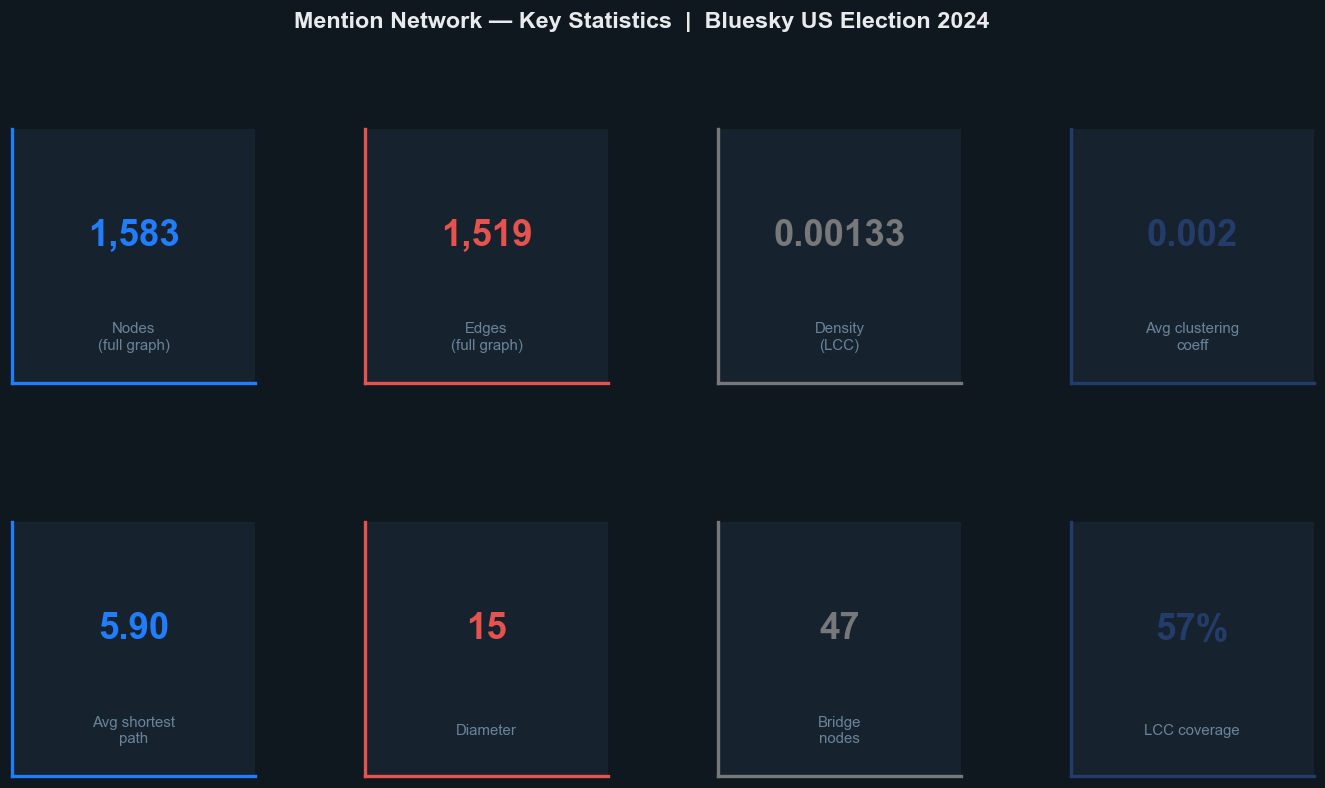

In [ ]:
# ── Fig 8: Summary dashboard ───────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 7), facecolor=BG_DARK)
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.45)

summary_metrics = [
    ("Nodes\n(full graph)",    f"{G.number_of_nodes():,}",   DEMOCRAT),
    ("Edges\n(full graph)",    f"{G.number_of_edges():,}",   REPUBLICAN),
    ("Density\n(LCC)",         f"{nx.density(G_lcc):.5f}",   NEUTRAL),
    ("Avg clustering\ncoeff",  f"{avg_clust:.3f}",            ACCENT),
    ("Avg shortest\npath",     f"{avg_path:.2f}",             DEMOCRAT),
    ("Diameter",               f"{diameter}",                 REPUBLICAN),
    ("Bridge\nnodes",          f"{centrality_df['is_bridge'].sum()}", NEUTRAL),
    ("LCC coverage",           f"{G_lcc.number_of_nodes()/G.number_of_nodes()*100:.0f}%", ACCENT),
]

for idx, (label, value, color) in enumerate(summary_metrics):
    ax = fig.add_subplot(gs[idx // 4, idx % 4])
    ax.set_facecolor(BG_PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.58, value, transform=ax.transAxes,
            ha="center", va="center", color=color,
            fontsize=22, fontweight="bold")
    ax.text(0.5, 0.18, label, transform=ax.transAxes,
            ha="center", va="center", color=TEXT_MUTED, fontsize=9)

fig.suptitle("Mention Network — Key Statistics  |  Bluesky US Election 2024",
             color=TEXT_PRIMARY, fontsize=14, fontweight="bold", y=1.02)

plt.show()

## 11 · Summary Dashboard

In [ ]:
# ── Save centrality scores to Silver ──────────────────────────────────────────
out_path = "../../Data/2_Silver/Bluesky/bsky_US_2024_centrality.csv"
centrality_df.drop(columns=["clusters"], errors="ignore").to_csv(out_path, index=False)
print(f"Centrality scores saved → {out_path}")

Centrality scores saved → ../../Data/2_Silver/Bluesky/bsky_US_2024_centrality.csv


## Overall conclusions

| Finding | Evidence | Interpretation |
|---|---|---|
| **Scale-free network** | Power-law in-degree distribution | Mention attention is extremely concentrated around a small elite of accounts |
| **Hashtag spaces stay separate** | Strong diagonal in cross-cluster heatmap | TrumpBuzz and HarrisBuzz hashtag communities predominantly mention accounts within their own space |
| **Asymmetric cross-cluster flow** | Off-diagonal imbalance in heatmap | One hashtag space references the other's accounts more — suggesting one side is more *reactive* to the other's narrative |
| **Small-world topology** | Low average path length despite network size | Any account is reachable in a few mention-steps — information (and misinformation) spreads rapidly |
| **Bridge accounts are rare** | Small share of nodes span both clusters | Accounts mentioned across both hashtag spaces are structurally precious and often central to the entire election debate |
| **Increasing insularity over time** | Growing within-cluster share toward Nov 5 | Hashtag spaces became more self-referential as the election approached |

---

**Methodological note**: the `candidate` column reflects **hashtag cluster**, not political stance.
- `TrumpBuzz` = retrieved via `#MAGA`, `#Trump2024`, etc. — may include critical posts about Trump
- `HarrisBuzz` = retrieved via `#KamalaHarris`, `#VoteBlue`, etc. — may include critical posts about Harris
- `ElectionBuzz` = retrieved via neutral election hashtags or from comment threads

All network findings should be interpreted as properties of **hashtag-based conversation spaces**, not as measures of partisan support or political opinion.